16:03:45 中国标准时间 WARNING: Structure at 'structures[0]' has bounds that     
                      extend exactly to simulation edges. This can cause        
                      unexpected behavior. If intending to extend the structure 
                      to infinity along one dimension, use td.inf as a size     
                      variable instead to make this explicit.                   

                WARNING: Suppressed 3 WARNING messages.                         

<Axes: title={'center': 'cross section at z=0.00'}, xlabel='x', ylabel='y'>

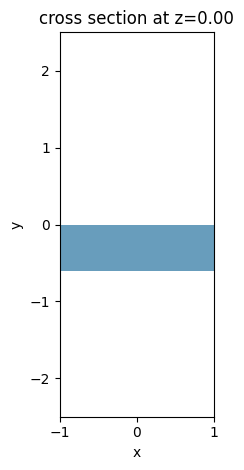

In [ ]:
import tidy3d as td
import numpy as np

s = 2  # the size of the computational cell, not including PML
dpml = 0.2  # thickness of PML layers

resolution = 25
sxy = (s + 2 * dpml)  # cell size, including PML
cell = (s, 5, s)
n = 1  # refractive index of material containing the source,没发求得带虚部的介质材料

star = 0.6
end = 0.9
df1 = 1 / star
df2 = 1 / end
wvl = (df1 + df2) / 2
fcen = wvl
df = df1 - df2

dl = 1/resolution

n = 1
nfreq = 300

# automatic grid specification
# grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wvl_um)
grid_spec = td.GridSpec.uniform(dl=dl)

# 结构的定义
r_bottom = 1
r_top = 0
n_cone = 2
# cone = [td.Cone(center=(0, 0.3, 0), radius=r_bottom, radius2=r_top, height=0.6, axis=Vector3(0, 1, 0),
#                 material=mp.Medium(index=n_cone))]

straight = td.Structure(
    geometry=td.Box(center=(0, -0.3, 0), size=(2, 0.6, 2)),
    medium=td.Medium.from_nk(n_cone, 0, fcen),
)

path_prefix = "D:\\workspace\\mymeep\\cmake-build-debug-visual-studio\\libcore\\"

sim = td.Simulation(
    size=cell,
    grid_spec=grid_spec,
    structures=[straight],
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
)

sim.plot(z=0.0)

In [2]:
import custom.spatial_medium as sm

creator = sm.SpatialMediumCreator4(sim)

medium, cell_permittivity = creator.create()

process total cells: 43264 on 20 cores, iterations: None
Calc Time elapsed: 284.4635769000015


[4.]


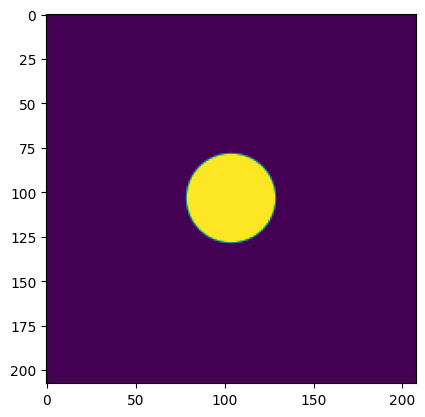

In [8]:
# vis
import matplotlib.pyplot as plt
print(cell_permittivity[100,100]);
plt.imshow(cell_permittivity.squeeze())

In [ ]:
# save as npy
np.save(path_prefix +"cone_medium-4.npy", cell_permittivity)

In [1]:
creator = sm.SpatialMediumCreator5(sim)

_, cell_permittivity = creator.create()

NameError: name 'sm' is not defined

In [ ]:
plt.imshow(cell_permittivity)
np.save(path_prefix +"cone_medium-5.npy", cell_permittivity)

NameError: name 'plt' is not defined